# Supplementary Figure: Tested Bin Performance with Confidence Intervals

This notebook loads per-bin evaluation outputs from `results/eval_once_bins_5_10_15_20_t05` and generates a single visualization comparing the tested bin sizes with 95% confidence intervals.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import sem, t

# NOTE: Evaluation naming changed from stacking_* to binned_*; this notebook supports both patterns.
FS_TITLE = 12
FS_SUBTITLE = 11
FS_LABEL = 12
FS_TICK = 11
FS_LEGEND = 10
FS_TEXT = 9

plt.style.use('default')
plt.rcParams.update({
    'font.size': FS_TEXT,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

base_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model')
results_dir = base_dir / 'results' / 'eval_once_bins_5_10_15_20_t05'
figures_dir = base_dir / 'figures'
figures_dir.mkdir(exist_ok=True)

pattern = re.compile(r'(?:binned|stacking_bin)_(\d+)_iteration_metrics\.csv$')
iteration_metric_files = sorted(
    (path for path in results_dir.glob('*_iteration_metrics.csv') if pattern.search(path.name)),
    key=lambda path: int(pattern.search(path.name).group(1)),
)

if not iteration_metric_files:
    raise FileNotFoundError(
        f'No binned/stacking bin iteration metric files found in: {results_dir}'
    )

print(f'Using results directory: {results_dir}')
print('Found tested bin files:')
for path in iteration_metric_files:
    print(f'  - {path.name}')

Using results directory: /home/tobamo/analize/project-tobamo/analysis/model/results/eval_once_bins_5_10_15_20_t05
Found tested bin files:
  - stacking_bin_5_iteration_metrics.csv
  - stacking_bin_10_iteration_metrics.csv
  - stacking_bin_15_iteration_metrics.csv
  - stacking_bin_20_iteration_metrics.csv


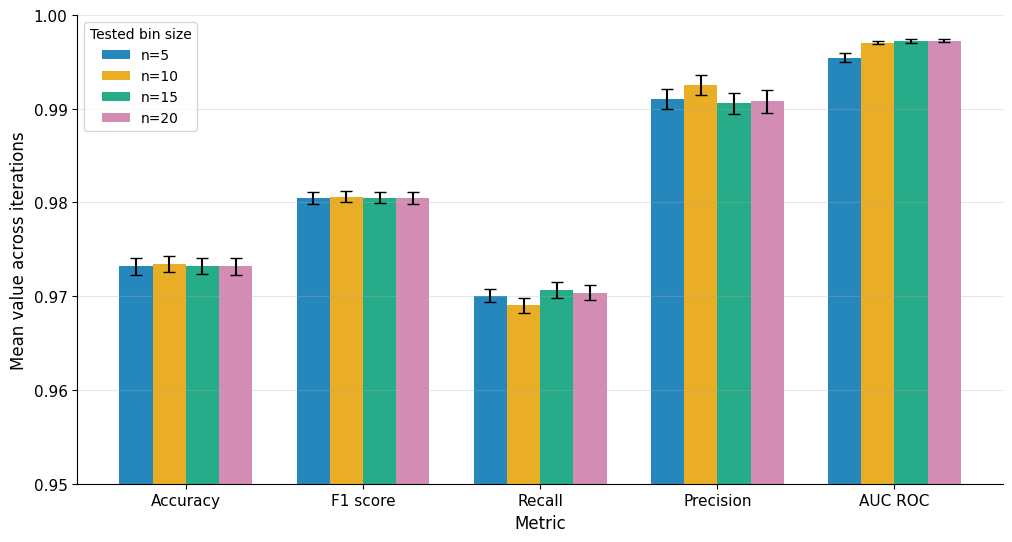

Saved figure to: /home/tobamo/analize/project-tobamo/analysis/model/figures/supp_fig4_bin_test.png
Tested bin values: [np.int64(5), np.int64(10), np.int64(15), np.int64(20)]


,n,metric,metric_label,mean,std,ci_lower,ci_upper
0,5,accuracy,Accuracy,0.9732,0.0024,0.9723,0.9741
1,5,f1,F1 score,0.9804,0.0018,0.9798,0.9811
2,5,recall,Recall,0.9701,0.0019,0.9694,0.9708
3,5,precision,Precision,0.9911,0.0029,0.9900,0.9922
4,5,auc,AUC ROC,0.9954,0.0013,0.9949,0.9959
5,10,accuracy,Accuracy,0.9735,0.0023,0.9726,0.9743
6,10,f1,F1 score,0.9806,0.0016,0.9800,0.9812
7,10,recall,Recall,0.9690,0.0022,0.9682,0.9699
8,10,precision,Precision,0.9925,0.0029,0.9914,0.9936
9,10,auc,AUC ROC,0.9971,0.0005,0.9969,0.9972


In [2]:
metric_specs = [
    ('accuracy', 'Accuracy'),
    ('f1', 'F1 score'),
    ('recall', 'Recall'),
    ('precision', 'Precision'),
    ('auc', 'AUC ROC'),
]

iteration_frames = []
for path in iteration_metric_files:
    match = pattern.search(path.name)
    n_value = int(match.group(1))
    frame = pd.read_csv(path)
    frame['n'] = n_value
    iteration_frames.append(frame)

metrics_df = pd.concat(iteration_frames, ignore_index=True)

confidence_level = 0.95
summary_rows = []
for n_value, grp in metrics_df.groupby('n', sort=True):
    for metric_key, metric_label in metric_specs:
        vals = grp[metric_key].to_numpy(dtype=float)
        mean = vals.mean()
        std = vals.std(ddof=1) if len(vals) > 1 else 0.0
        se = sem(vals) if len(vals) > 1 else 0.0
        h = se * t.ppf((1 + confidence_level) / 2, len(vals) - 1) if len(vals) > 1 else 0.0
        summary_rows.append({
            'n': n_value,
            'metric': metric_key,
            'metric_label': metric_label,
            'mean': mean,
            'std': std,
            'ci_lower': mean - h,
            'ci_upper': mean + h,
        })

summary_df = pd.DataFrame(summary_rows)
bins = sorted(summary_df['n'].unique())

means = np.array([
    [summary_df[(summary_df['n'] == n_value) & (summary_df['metric'] == metric_key)]['mean'].iloc[0] for metric_key, _ in metric_specs]
    for n_value in bins
])
ci_lowers = np.array([
    [summary_df[(summary_df['n'] == n_value) & (summary_df['metric'] == metric_key)]['ci_lower'].iloc[0] for metric_key, _ in metric_specs]
    for n_value in bins
])
ci_uppers = np.array([
    [summary_df[(summary_df['n'] == n_value) & (summary_df['metric'] == metric_key)]['ci_upper'].iloc[0] for metric_key, _ in metric_specs]
    for n_value in bins
])

lower_err = means - ci_lowers
upper_err = ci_uppers - means

x = np.arange(len(metric_specs))
width = 0.75 / len(bins)
y_min = max(0.0, ci_lowers.min() - 0.002)
y_max = min(1.0, ci_uppers.max() + 0.002)
colorblind_palette = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#D55E00', '#56B4E9']
bin_colors = colorblind_palette[:len(bins)]

fig, ax = plt.subplots(figsize=(12, 5.5))
for i, n_value in enumerate(bins):
    ax.bar(
        x + i * width,
        means[i],
        width,
        yerr=[lower_err[i], upper_err[i]],
        capsize=4,
        alpha=0.85,
        color=bin_colors[i],
        label=f'n={n_value}',
    )

ax.set_xticks(x + width * (len(bins) - 1) / 2)
ax.set_xticklabels([label for _, label in metric_specs], fontsize=FS_TICK)
ax.set_xlabel('Metric', fontsize=FS_LABEL)
ax.set_ylabel('Mean value across iterations', fontsize=FS_LABEL)
ax.set_ylim(0.95, 1)
# ax.set_title('Tested bin performance with 95% confidence intervals', fontsize=FS_TITLE)
ax.tick_params(axis='y', labelsize=FS_TICK)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper left',fontsize=FS_LEGEND, title='Tested bin size', title_fontsize=FS_LEGEND)

plt.tight_layout(rect=[0, 0, 0.85, 1])
output_path = figures_dir / 'supp_fig4_bin_test.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

print(f'Saved figure to: {output_path}')
print(f'Tested bin values: {bins}')
display(summary_df.round(4))